In [8]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import platform
import random
from collections import OrderedDict
import jupyter_client
import jupyterlab
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import scipy
import seaborn as sns
from IPython.display import display
from notebook import __version__ as nb_ver

np.set_printoptions(precision=60, threshold=20, edgeitems=8, suppress=True, linewidth=999, sign=' ', floatmode='maxprec_equal')
SEED = 1010336213
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
pd.set_option('display.precision', 3)
pd.set_option('display.html.border', 0)
pd.set_option('mode.chained_assignment', 'raise')
pd.set_option('display.colheader_justify', 'center')

plt.rcParams['agg.path.chunksize'] = 10000
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = 16.0, 10.0
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['image.interpolation'] = 'None'
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['savefig.bbox'] = 'tight'

sns.set()
sns.set(font_scale=0.8)
plt.style.use("dark_background")
sns.set_context(rc={'patch.linewidth': 0.0})
sns.set_style({
    'axes.axisbelow': False,
    'grid.color': '#ccc',
    'grid.alpha': 0.33,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'axes.facecolor': '#111',
    'axes.edgecolor': '#ccc',
    'axes.grid': True,
    'axes.labelcolor': '#ccc',
    'figure.facecolor': '#111',
    'text.color': '#ccc',
    'xtick.color': '#ccc',
    'ytick.color': '#ccc',
    'patch.edgecolor': '#ccc',
})
sns.set_palette("pastel")

plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.axis'] = 'both'
plt.rcParams['axes.grid.which'] = 'major'
plt.rcParams['grid.alpha'] = 0.33
plt.rcParams['grid.color'] = '#ccc'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Fixed random seed for better reproducibility
SEED = 4146516932
random.seed(SEED)
np.random.seed(SEED)

versions = pd.DataFrame.from_dict(OrderedDict([
    ('Operating system', ' '.join([platform.system(), platform.processor()])),
    ('Python', platform.python_version()),
    ('Jupyter', jupyter_client.__version__),
    ('Jupyter Notebook', nb_ver),
    ('Jupyter Lab', jupyterlab.__version__),
    ('Matplotlib', matplotlib.__version__),
    ('Seaborn', sns.__version__),
    ('Numpy', np.__version__),
    ('Pandas', pd.__version__),
    ('Plotly', plotly.__version__),
    ('SciPy', scipy.__version__),
]), orient='index')
versions.columns = ['Version']
display(versions)

,Version
Operating system,Linux
Python,3.12.11
Jupyter,8.6.3
Jupyter Notebook,7.4.5
Jupyter Lab,4.4.7
Matplotlib,3.10.6
Seaborn,0.13.2
Numpy,2.3.3
Pandas,2.3.2
Plotly,6.3.0


# Gaussian Convolution Demonstration

This notebook demonstrates the convolution of two Gaussian probability density functions, comparing numerical integration with the analytical solution.

## Define Convolution Function

Numerical convolution using discrete integration (Riemann sum):
$(f * g)(x) = \int_{-\infty}^{\infty} f(s)\,g(x-s)\,ds \approx \sum_{i} f(s_i)\,g(x-s_i)\,\Delta s$

where $\Delta s$ is the grid spacing.

In [9]:
def convolve(f, g, x, s_grid):
    """Numerical convolution using discrete integration (Riemann sum)."""
    ds = s_grid[1] - s_grid[0]  # Grid spacing Δs
    return ds * np.sum(f(s_grid) * g(x - s_grid))

## Gaussian Parameters

Define the parameters for our two Gaussian functions:
- $f(x)$: Standard deviation $\sigma_f = 1$, centered at 0
- $g(x)$: Standard deviation $\sigma_g = 1$, centered at $\mu = 1$

In [10]:
# Gaussian parameters - corresponds to convolution.md Section 1
sigma_g = 1  # σ_g in reference
sigma_f = 2  # σ_f in reference
mu = 1       # μ in reference (offset for g(x))

## Define Gaussian Functions

Both functions are normalized probability density functions:

- $f(x) = \frac{1}{\sqrt{2\pi\sigma_f^2}} \exp\left(-\frac{x^2}{2\sigma_f^2}\right)$
- $g(x) = \frac{1}{\sqrt{2\pi\sigma_g^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma_g^2}\right)$

In [11]:
def f(x):
    """Gaussian PDF: σ_f=1, centered at 0"""
    return np.exp(-0.5 * (x / sigma_f) ** 2) / (sigma_f * np.sqrt(2 * np.pi))

def g(x):
    """Gaussian PDF: σ_g=1, centered at μ=1"""
    return np.exp(-0.5 * ((x - mu) / sigma_g) ** 2) / (sigma_g * np.sqrt(2 * np.pi))

## Analytical Solution

The convolution of two Gaussians is another Gaussian:

$(f * g)(x) = \frac{1}{\sqrt{2\pi(\sigma_f^2 + \sigma_g^2)}} \exp\left(-\frac{(x-\mu)^2}{2(\sigma_f^2 + \sigma_g^2)}\right)$

- Mean: $\mu$ (from the offset Gaussian)
- Variance: $\sigma_f^2 + \sigma_g^2$ (variances add)

In [12]:
def analytical_result(x):
    """Analytical convolution of two Gaussians"""
    variance_sum = sigma_g ** 2 + sigma_f ** 2
    return np.exp(-0.5 * (x - mu) ** 2 / variance_sum) / np.sqrt(2 * np.pi * variance_sum)

## Compute Numerical Convolution

Set up grids and compute the convolution numerically:

In [13]:
# Integration grid for convolution (s variable)
s_grid = np.linspace(-5, 5, 101)

# Evaluation points for output
x_grid = np.linspace(-9, 11, 101)

# Compute numerical convolution
numerical_result = []
for x in x_grid:
    numerical_result.append(convolve(f, g, x, s_grid))

numerical_result = np.array(numerical_result)

## Visualization

Compare the numerical and analytical results:

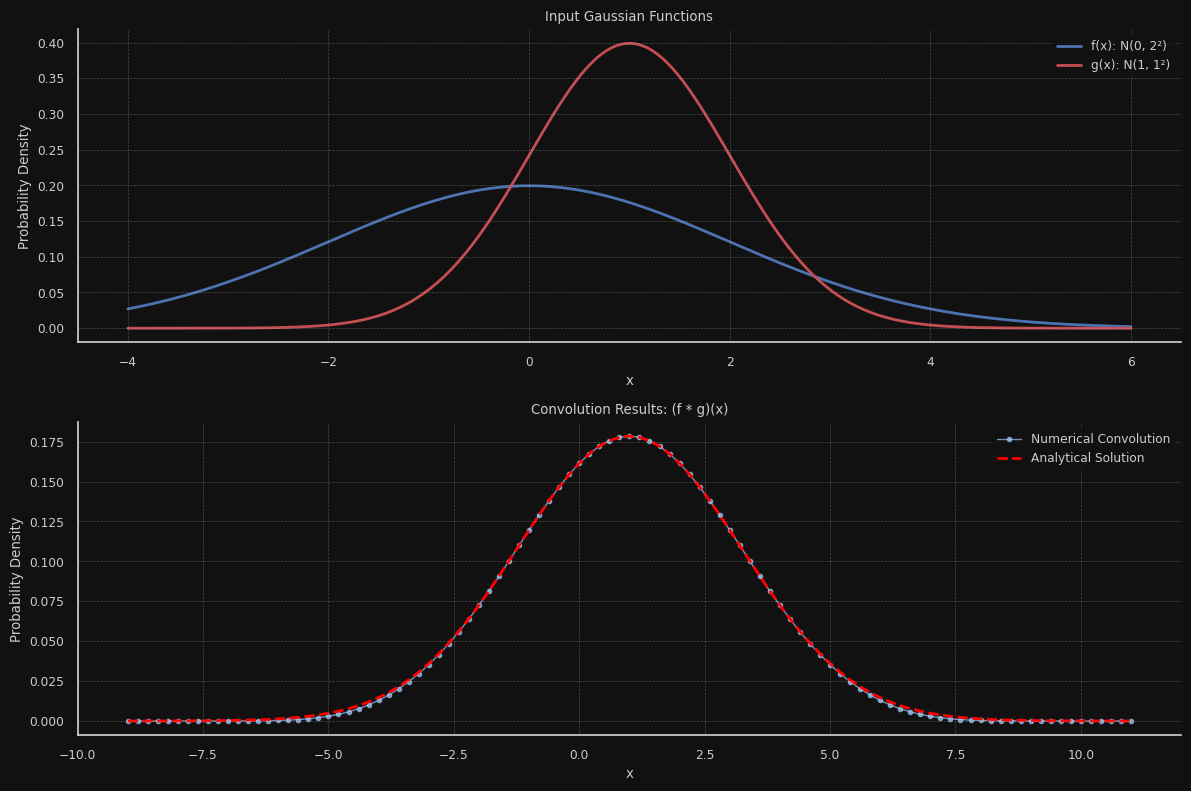

In [14]:
plt.figure(figsize=(12, 8))

# Plot input functions
plt.subplot(2, 1, 1)
x_input = np.linspace(-4, 6, 200)
plt.plot(x_input, f(x_input), 'b-', label=f'f(x): N(0, {sigma_f}²)', linewidth=2)
plt.plot(x_input, g(x_input), 'r-', label=f'g(x): N({mu}, {sigma_g}²)', linewidth=2)
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Input Gaussian Functions')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot convolution results
plt.subplot(2, 1, 2)
plt.plot(x_grid, numerical_result, 'o-', label='Numerical Convolution', 
         markersize=3, linewidth=1, alpha=0.7)
plt.plot(x_grid, analytical_result(x_grid), '--', label='Analytical Solution', 
         linewidth=2, color='red')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Convolution Results: (f * g)(x)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Error Analysis

Quantify the difference between numerical and analytical solutions:

Maximum absolute error: 0.002030
Mean absolute error: 0.000572
Maximum relative error: 0.999516
Mean relative error: 0.375010


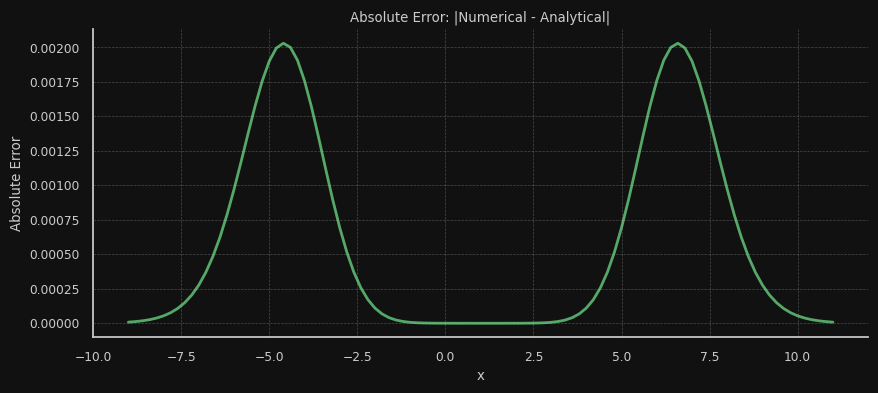

In [15]:
# Calculate error metrics
analytical_values = analytical_result(x_grid)
absolute_error = np.abs(numerical_result - analytical_values)
relative_error = absolute_error / (analytical_values + 1e-15)  # Avoid division by zero

print(f"Maximum absolute error: {np.max(absolute_error):.6f}")
print(f"Mean absolute error: {np.mean(absolute_error):.6f}")
print(f"Maximum relative error: {np.max(relative_error):.6f}")
print(f"Mean relative error: {np.mean(relative_error):.6f}")

# Plot error
plt.figure(figsize=(10, 4))
plt.plot(x_grid, absolute_error, 'g-', linewidth=2)
plt.xlabel('x')
plt.ylabel('Absolute Error')
plt.title('Absolute Error: |Numerical - Analytical|')
plt.grid(True, alpha=0.3)
plt.show()

## Key Properties Verification

Verify that the convolution result has the expected properties:

In [16]:
# Expected properties of the convolution result
expected_mean = mu
expected_variance = sigma_f**2 + sigma_g**2
expected_std = np.sqrt(expected_variance)

print(f"Expected mean: {expected_mean}")
print(f"Expected standard deviation: {expected_std:.3f}")
print(f"Expected variance: {expected_variance}")

# Numerical integration to verify PDF properties
dx = x_grid[1] - x_grid[0]
total_area = np.sum(analytical_values) * dx
numerical_mean = np.sum(x_grid * analytical_values) * dx
numerical_variance = np.sum((x_grid - numerical_mean)**2 * analytical_values) * dx

print(f"\nNumerical verification:")
print(f"Total area under curve: {total_area:.6f} (should be ≈ 1.0)")
print(f"Numerical mean: {numerical_mean:.6f}")
print(f"Numerical variance: {numerical_variance:.6f}")
print(f"Numerical std: {np.sqrt(numerical_variance):.6f}")

Expected mean: 1
Expected standard deviation: 2.236
Expected variance: 5

Numerical verification:
Total area under curve: 0.999994 (should be ≈ 1.0)
Numerical mean: 0.999994
Numerical variance: 4.999304
Numerical std: 2.235912
